In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import skew

## а) Определить по выборке моду, медиану, размах, оценку коэффицента ассиметрии 

In [5]:
n = 25
sample = np.random.exponential(scale=1, size=n)
print(sample)

#Расчет моды
moda = sample[np.argmax(np.bincount(sample.astype(int)))]
print(f"Mode: {moda:.2f}")

#Расчет медианы
mediana = np.median(sample)
print(f"Mediana: {mediana:.2f}")

#Расчет размаха
range_value = np.ptp(sample)
print(f"Range: {range_value:.2f}")

#Расчет оценки коэффицента ассиметрии
skewness = skew(sample)
print(f"Skewness: {skewness:.2f}")

[0.83745778 0.29380833 0.39508199 2.38781372 0.34570221 1.32115924
 1.27910045 0.694589   1.21975125 1.13736573 2.40507856 3.69288873
 0.03542025 0.22108718 1.54383419 0.59694947 0.17694967 2.26452924
 0.35104537 1.16426132 0.73786012 0.03655107 0.58586539 1.21389429
 1.1892835 ]
Mode: 0.84
Mediana: 0.84
Range: 3.66
Skewness: 1.27


## б) Построить эмпирическую функцию распределения, гистограмму и boxplot

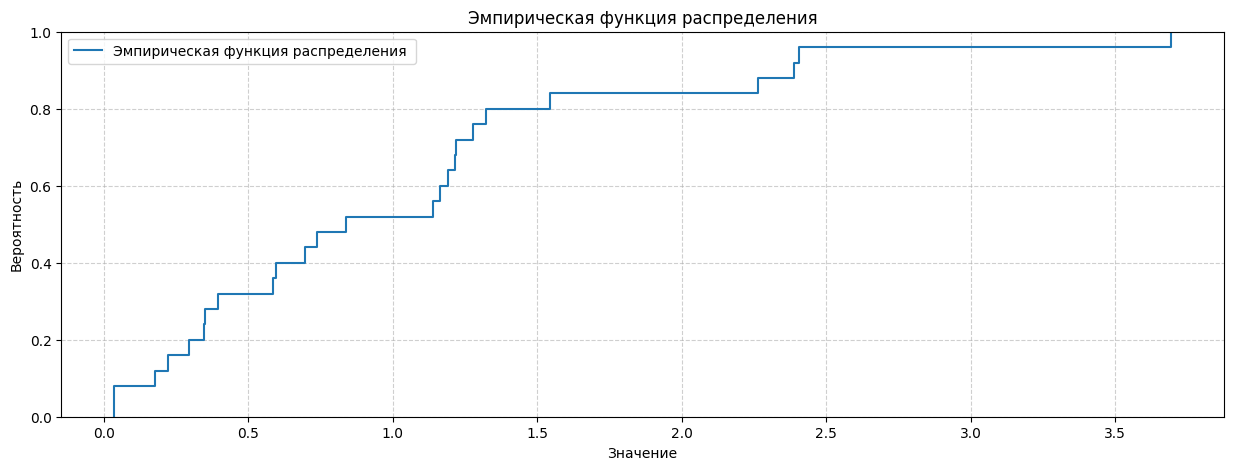

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.ecdf(sample, label='Эмпирическая функция распределения ')
ax.set_title('Эмпирическая функция распределения')
ax.set_xlabel('Значение')
ax.set_ylabel('Вероятность')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

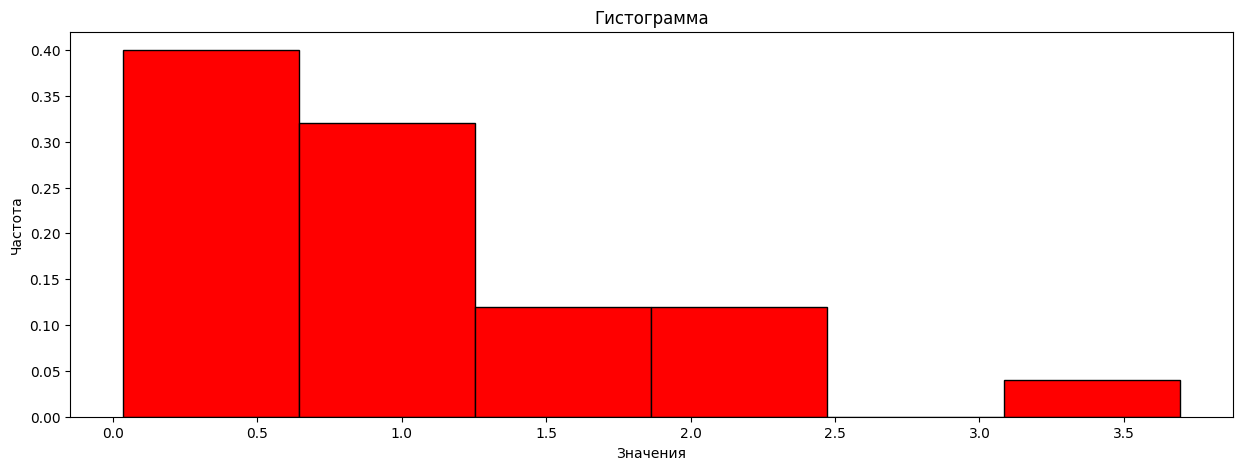

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
n = len(sample)
k = int(math.ceil(1 + np.log2(n)))
plt.hist(sample, bins=k, weights=np.ones_like(sample)/len(sample), color='red',edgecolor = 'black')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.title('Гистограмма')
plt.show()

Text(0.5, 1.0, 'boxplot')

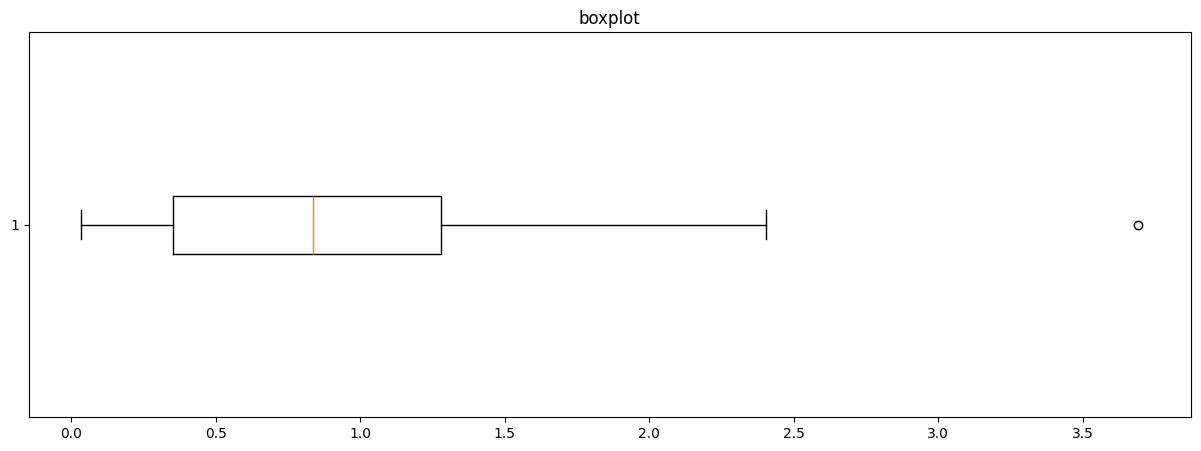

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.boxplot(sample,vert=False)
plt.title('boxplot')

## с) Сравнить оценку плотности распределения среднего арифметического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности

Выборочное среднее :1.05
Стандартная ошибка :0.18


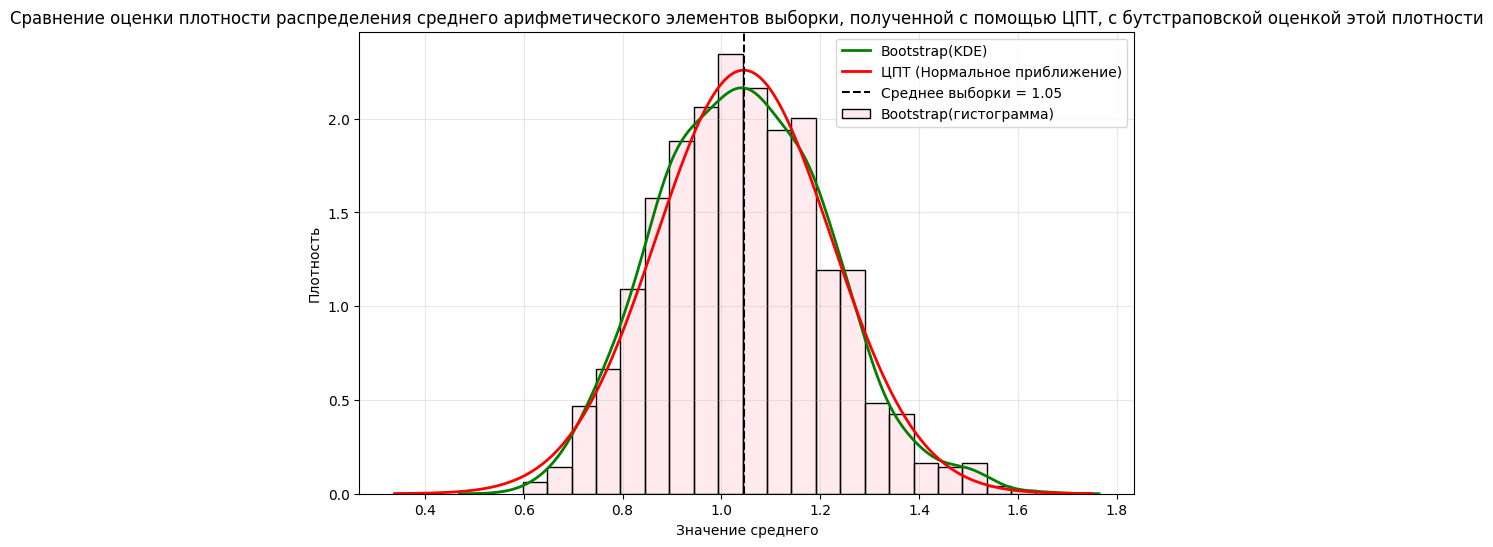

In [17]:
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
std_error = sample_std/np.sqrt(n)

print(f"Выборочное среднее :{sample_mean:.2f}")
print(f"Стандартная ошибка :{std_error:.2f}")

n_boodstrap = 1000
boodstrap_mean = np.empty(n_boodstrap)

for i in range(n_boodstrap):
    bootstrap_sample = np.random.choice(sample, size=n, replace=True)
    boodstrap_mean[i] = np.mean(bootstrap_sample)

plt.figure(figsize=(10,6))
sns.histplot(boodstrap_mean, stat='density', alpha=0.3, label='Bootstrap(гистограмма)', color='pink')
sns.kdeplot(boodstrap_mean, label='Bootstrap(KDE)', color='green', linewidth=2)

x = np.linspace(sample_mean - 4*std_error, sample_mean + 4*std_error, 200)
normal_pdf = sp.stats.norm.pdf(x, loc=sample_mean, scale=std_error)
plt.plot(x, normal_pdf, 'r-', linewidth=2, label='ЦПТ (Нормальное приближение)')

plt.axvline(sample_mean, color='black', linestyle='--', label=f'Среднее выборки = {sample_mean:.2f}')

plt.title('Сравнение оценки плотности распределения среднего арифметического элементов выборки, полученной с помощью ЦПТ, с бутстраповской оценкой этой плотности')
plt.xlabel('Значение среднего')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## d) Найти бутсраповскую оценку плотности распределения коэффицента ассиметрии и оценить вероятность того, что коэффицент асимметрии будет меньше 1

[ 1.0675833   1.77138344  1.40090514  0.85413124  0.05455875  1.1105478
  1.45884414  1.46961585  1.84493264  1.01925939  0.77099353  0.7547854
  0.84652632  1.07663521  1.56120122  1.62351878  1.60685917  0.7353436
  0.73937439  0.45847118  1.99439265  1.28058507  0.62242058  1.04263451
  0.84107297  0.49131363  1.1762507   1.01521388  0.30227633  1.80812926
  0.95965947  1.2706321   0.59057246  1.23566745  0.81401022  1.16573372
  0.43545076  1.90364962  0.82509167 -0.43087924  0.65648304  0.96033176
  0.97422489  0.21116802  1.27813381  0.87366816  1.71524094  1.14827286
  0.77215248  1.46560345  0.33160786  2.00677741  1.3091121   1.07959695
  1.71557757  0.8652293   1.81375835  1.75429013  1.04910281  0.64206082
  1.45964266  0.67218946  1.55131343  0.71540961  1.34973402  1.0424345
  1.40565866  0.83517838  1.12234118  0.81575064  1.43081607  1.12151424
  0.47826534  1.09819973  1.4594295   1.50916574  1.46535908  0.40403995
  1.11127286  1.5089086   1.65923618  0.08731821  1.368

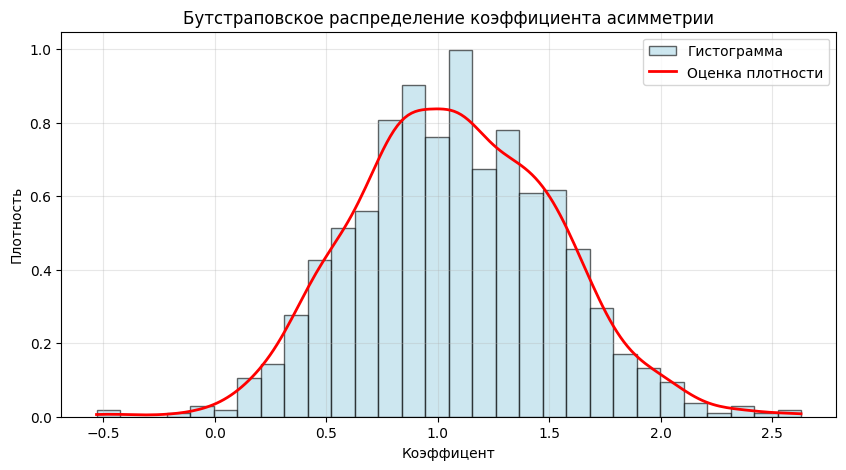

Оценка вероятности P(skewness < 1) = 0.45


In [24]:
n_boodstrap = 1000
n = len(sample)

bootstrap_skewness = np.zeros(n_boodstrap)

for i in range(n_boodstrap):
    sample_skewness = np.random.choice(sample, size=n, replace=True)
    bootstrap_skewness[i] = sp.stats.skew(sample_skewness)

print(bootstrap_skewness)
plt.figure(figsize=(10,5))
plt.hist(bootstrap_skewness, bins=30, density=True, alpha=0.6, color='lightblue', edgecolor='black', label='Гистограмма')

kde = sp.stats.gaussian_kde(bootstrap_skewness)
x_grid = np.linspace(min(bootstrap_skewness), max(bootstrap_skewness), 200)
plt.plot(x_grid, kde(x_grid), color='red', linewidth=2, label='Оценка плотности')

plt.title('Бутстраповское распределение коэффициента асимметрии')
plt.xlabel('Коэффицент')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

prob_less_1 = np.mean(bootstrap_skewness < 1)
print(f"Оценка вероятности P(skewness < 1) = {prob_less_1:.2f}")

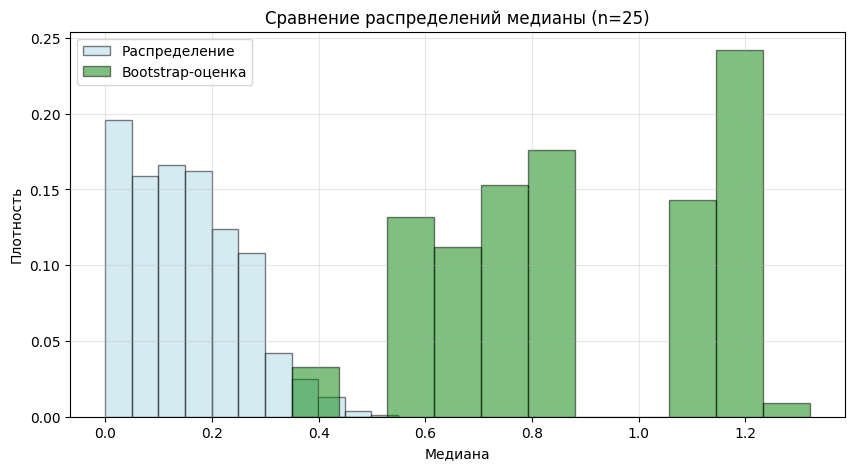

In [30]:
n = 25
B = 1000
R = 1000

true_medians = []
for _ in range(B):
    x = np.random.exponential(scale=1, size=n)
    x[x > 1] = 0
    true_medians.append(np.median(x))
true_medians = np.array(true_medians)

bootstrap_medians = []
for _ in range(R):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    bootstrap_medians.append(np.median(boot_sample))
bootstrap_medians = np.array(bootstrap_medians)


plt.figure(figsize=(10, 5))
plt.hist(true_medians, bins=11, weights=np.ones_like(true_medians)/1000, alpha=0.5, color="lightblue", edgecolor='black', label='Распределение')
plt.hist(bootstrap_medians, bins=11, weights=np.ones_like(true_medians)/1000, alpha=0.5, color= "green", edgecolor='black', label='Bootstrap-оценка')
plt.xlabel('Медиана')
plt.ylabel('Плотность')
plt.title('Сравнение распределений медианы (n=25)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()